In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import random

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

from scipy.stats import binom, poisson

In [4]:
XXSMALL_SIZE = 8
XSMALL_SIZE = 10
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

In [5]:
alphabet = ["A", "C", "G", "T"]
kmers = []
for c1 in alphabet:
    for c2 in alphabet:
        for c3 in alphabet:
            kmers.append(c1 + c2 + c3)

In [6]:
def read_dump(file_in):
    df = pd.read_csv(file_in, sep = "\t", header = None)
    df.columns  = ["kmer", "count"]
    return df

### k-mer count histogram

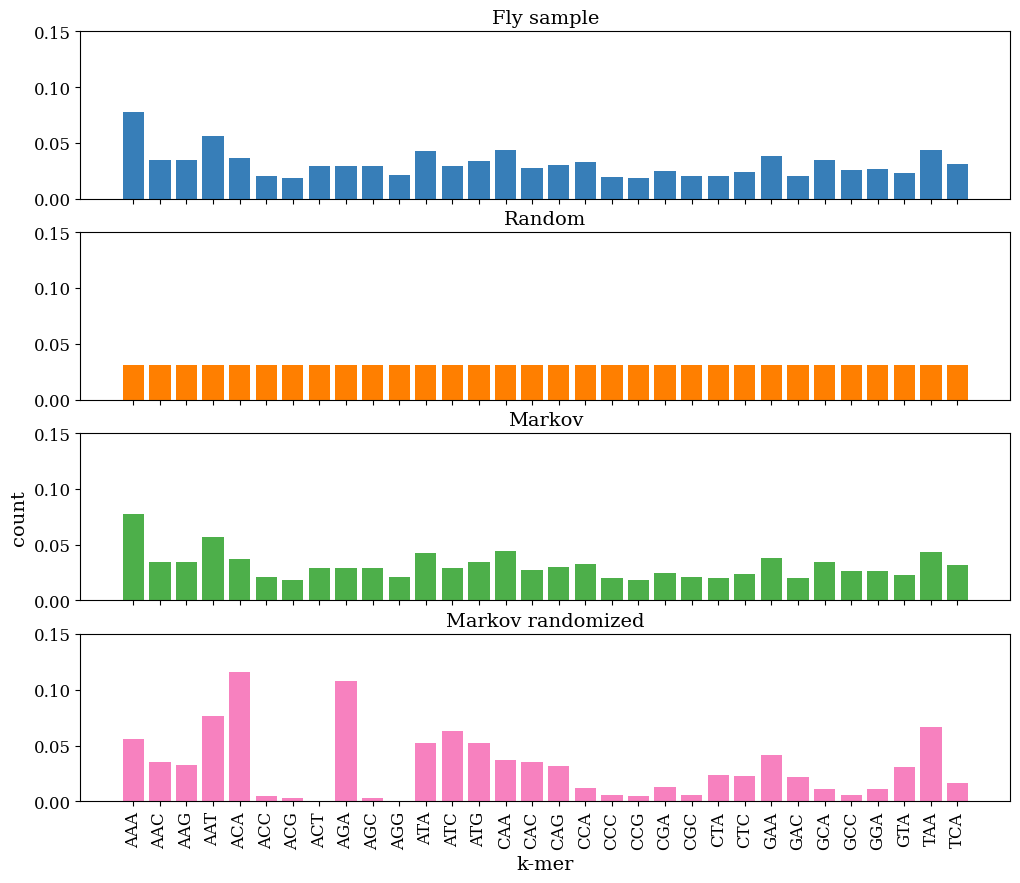

In [7]:
fig, ax = plt.subplots(4, 1, sharex = True, figsize = (12, 10))
df = read_dump("data/fly.3mer.dump")
ax[0].bar(df["kmer"], df["count"]/np.sum(df["count"]), color = CB_color_cycle[0])
ax[0].set_title("Fly sample")

df = read_dump("data/sim.3mer.dump")
ax[1].bar(df["kmer"], df["count"]/np.sum(df["count"]), color = CB_color_cycle[1])
ax[1].set_title("Random")

df = read_dump("data/sim_markov_3mer.dump")
ax[2].bar(df["kmer"], df["count"]/np.sum(df["count"]), color = CB_color_cycle[2])
ax[2].set_title("Markov")

df = read_dump("data/sim_markov_rand_3mer.dump")
ax[3].bar(df["kmer"], df["count"]/np.sum(df["count"]), color = CB_color_cycle[3])
ax[3].set_title("Markov randomized")

ax[2].set_ylabel("count")
ax[3].set_xlabel("k-mer")

for i in range(4):
    ax[i].set_ylim(0, 0.15)

xt = plt.xticks(rotation = "vertical")

## Read k-mer spectra

In [8]:
def read_occ_table(path):
    df = pd.read_csv(path, sep = "\t", header = None)
    df.columns = ["count", "occurrences"]
    df["frequency"] = df["count"] / np.sum(df["count"])
    if (abs(1 - np.sum(df["frequency"])) > 0.05):
        print("Incorrect frequency")
    return df

In [9]:
def plot_abundance(ax, df, abundance_thresh, max_freq, name, colorname):
    df_low_abundance = df.loc[df['occurrences'] <= abundance_thresh]
    ax.bar(df_low_abundance["occurrences"], df_low_abundance["frequency"], width = 1.0, color = colorname, label = name, alpha=0.65)
    #ax.legend(loc = "upper right")
    ax.set_xlim([-abundance_thresh*0.01, abundance_thresh])
    ax.set_ylim(0, max_freq)
    #ax.set_title(name, fontsize = MEDIUM_SIZE)

In [10]:
def plot_poisson(ax, df):
    trials = np.sum(df["occurrences"] * df["count"])
    distinct_kmers = np.sum(df["count"])
    expected_lambda = int(trials / distinct_kmers)
    print("Expected " + str(expected_lambda) + " hits in " + str(trials) + " trials")

    # numerical overflow
    #df["poisson_probability"] = df.apply(lambda row: math.e**(-expected_lambda) * expected_lambda**row.occurrences / math.factorial(int(row.occurrences)), axis=1)

    x = np.arange(poisson.ppf(0.001, expected_lambda),
                  poisson.ppf(0.999, expected_lambda))

    ax.plot(x, poisson.pmf(x, expected_lambda), color = "black", label = r"Po($\lambda$=" + str(expected_lambda) + ")")

print("k\tlambda\tdistinct_count")
for k in [3, 5, 7, 9, 11, 13, 15]:
    o = 3
    df = markov_occ = read_occ_table("data/simulated_fly_size/from_fly_markov_o" + str(o) + ".fa." + str(k) + "mer.tsv")
    trials = np.sum(df["occurrences"] * df["count"])
    distinct_kmers = np.sum(df["count"])
    expected_lambda = int(trials / distinct_kmers)
    print(str(k) + "\t" + str(expected_lambda) + "\t" + str(np.max(df["occurrences"])))

k	lambda	distinct_count
3	4547640	10162972
5	284227	1312232
7	17764	169692
9	1110	22381
11	69	2968
13	4	363
15	1	46


### Published results

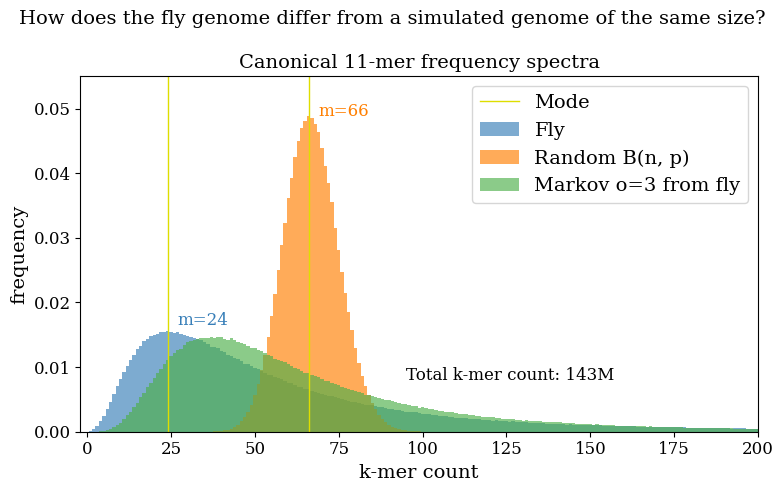

In [11]:
fig, ax = plt.subplots(1)
fig.set_figheight(5)
fig.set_figwidth(8)
fig.suptitle("How does the fly genome differ from a simulated genome of the same size?")

# plot binomial trial
# ax.plot(maso_occ["occurrences"], rand_occ["frequency"], color = CB_color_cycle[6], label = "B(n,p)", alpha = 0.5)

fly_occ = read_occ_table("data/fly_k11.tsv")
mason_occ = read_occ_table("data/sim_mason_k11.tsv")

plot_abundance(ax, fly_occ, 200, 0.055, "Fly", CB_color_cycle[0])
plot_abundance(ax, mason_occ, 200, 0.055, "Random B(n, p)", CB_color_cycle[1])


o=3
markov_occ = read_occ_table("data/simulated_fly_size/from_fly_markov_o" + str(o) + ".fa.11mer.tsv")
plot_abundance(ax, markov_occ, 200, 0.055, "Markov o=" + str(o) + " from fly", CB_color_cycle[2])

ab_mode = fly_occ["occurrences"][np.argmax(fly_occ["count"])]
ax.axvline(ab_mode, linewidth = 1, label = "Mode", color = CB_color_cycle[8])
ax.text(ab_mode + 3, fly_occ["frequency"][np.argmax(fly_occ["count"])] + 0.001, "m=" + str(ab_mode), size = SMALL_SIZE, color = CB_color_cycle[0])

ab_mode = mason_occ["occurrences"][np.argmax(mason_occ["count"])]
ax.axvline(ab_mode, linewidth = 1, color = CB_color_cycle[8])
ax.text(ab_mode + 3, mason_occ["frequency"][np.argmax(mason_occ["count"])], "m=" + str(ab_mode), size = SMALL_SIZE, color = CB_color_cycle[1])

#ab_mode = rand_occ["occurrences"][np.argmax(rand_occ["count"])]
#ax.axvline(ab_mode, linewidth = 1, color = CB_color_cycle[4], alpha = 0.75)

ax.text(95, 0.008, "Total k-mer count: 143M", size = SMALL_SIZE)
#ax.text(95, 0.004, "E(x)=" + str(round(np.sum(markov_occ["count"] * markov_occ["occurrences"]) / np.sum(markov_occ["count"]))), size = XSMALL_SIZE)

#ax.text(110, 0.005, "Max k-mer count: " + str(np.max(fly_occ["occurrences"])), size = XSMALL_SIZE, color = c_darkgreen)
#ax.text(110, 0.02, "Total k-mer count: " + str(np.sum(markov_occ["count"] * markov_occ["occurrences"])), size = XSMALL_SIZE, color = CB_color_cycle[6])

ax.set_title("Canonical 11-mer frequency spectra")

ax.legend(loc = "upper right")
ax.set_xlabel("k-mer count")
ax.set_ylabel("frequency")

#handles, labels = ax1.get_legend_handles_labels()
#fig.legend(handles, labels, bbox_to_anchor=(0.935,0.75))

fig.tight_layout()
fig.savefig('140Mb_spectra_RM.png', dpi = 200)

### k-mer distribution divergence

#### Total variation distance

An absolute value. We do not know the distribution of this value given the assumption that the reference and simulated dataset stem from the same distribution

In [12]:
def total_var_dist(d1, d2):
    data = d1.merge(d2, how = "outer", on = "occurrences").fillna(0)
    dist = 0
    for index, row in data.iterrows():    
        dist += abs(row["count_x"] - row["count_y"])
    return(dist / 2)

In [13]:
print("k\torder\tmason-div\tmarkov-div")
for k in [7, 9, 11, 13, 15, 17, 19, 21, 23]:
    ref_occ = read_occ_table("data/fly/dna4.fasta." + str(k) + "mer.tsv")
    mason_occ = read_occ_table("data/simulated_fly_size/mason.fa." + str(k) + "mer.tsv")
    for o in [4, 6, 8, 10, 12, 14, 16]:
        markov_occ = read_occ_table("data/simulated_fly_size/from_fly_markov_o" + str(o) + ".fa." + str(k) + "mer.tsv")    
        print(str(k) + "\t" + str(o) + "\t" + str(total_var_dist(ref_occ, mason_occ)) + "\t" + str(total_var_dist(ref_occ, markov_occ)))

k	order	mason-div	markov-div
7	4	7968.0	6240.0
7	6	7968.0	6253.0
7	8	7968.0	6200.0
7	10	7968.0	6238.0
7	12	7968.0	6214.0
7	14	7968.0	7556.0
7	16	7968.0	7131.0
9	4	117958.0	13317.0
9	6	117958.0	12484.0
9	8	117958.0	12169.0
9	10	117958.0	11910.0
9	12	117958.0	12400.0
9	14	117958.0	90109.0
9	16	117958.0	72951.5
11	4	1548258.5	208005.5
11	6	1548258.5	162546.0
11	8	1548258.5	122267.0
11	10	1548258.5	61718.5
11	12	1548258.5	70145.5
11	14	1548258.5	1073756.0
11	16	1548258.5	1001197.5
13	4	10928632.0	3014092.5
13	6	10928632.0	2580553.0
13	8	10928632.0	2116899.0
13	10	10928632.0	1568103.5
13	12	10928632.0	1888693.0
13	14	10928632.0	12117786.0
13	16	10928632.0	13492135.0
15	4	22021050.0	12584493.5
15	6	22021050.0	11289288.5
15	8	22021050.0	9666134.0
15	10	22021050.0	7703246.0
15	12	22021050.0	4391711.5
15	14	22021050.0	42158801.5
15	16	22021050.0	42823080.0
17	4	18880220.0	16540425.0
17	6	18880220.0	15881692.0
17	8	18880220.0	14775299.0
17	10	18880220.0	13314765.5
17	12	18880220.0	9062860.5
17	1

#### Kullback-Leibler divergence

How much the approximating probability distribution (the sample) is different from a true probability distribution (the reference)

Is not defined if the reference distribution is non-zero and the sample distribution is zero

In [14]:
# Relative entropy between the k-mer spectra
# How many k-mers (count) appear 14 times (occurrences) in both datasets?
# NOT: how many times does ATC appear in both datasets
def relative_entropy(true_df, model_df):
    data = true_df.merge(model_df, how = "outer", on = "occurrences").fillna(0)
    dist = 0
    #print(data[(data["frequency_x"]>0) & (data["frequency_y"]>0)])
    for index, row in data.iterrows():
        if (row["frequency_x"] != 0):
            if (row["frequency_y"] == 0):
                # TODO: smoothing
                #print("Kullback-Leibler divergence is not defined when P(x)!=0 and Q(x)==0")
                continue
            else:
                dist += row["frequency_x"] * math.log(row["frequency_x"] / row["frequency_y"], 2)
                #print(dist)
            #print(dist)
    return round(dist, 10)

In [15]:
print("k\torder\tmason-div\tmarkov-div")
#for k in [7, 9, 11, 13, 15, 17, 19, 21, 23]:
for k in [11]:
    ref_occ = read_occ_table("data/fly/dna4.fasta." + str(k) + "mer.tsv")
    mason_occ = read_occ_table("data/simulated_fly_size/mason.fa." + str(k) + "mer.tsv")
    #for o in [4, 6, 8, 10, 12, 14, 16]:
    mason_div = relative_entropy(ref_occ, mason_occ)
    for o in [4, 10]:
        markov_occ = read_occ_table("data/simulated_fly_size/from_fly_markov_o" + str(o) + ".fa." + str(k) + "mer.tsv")    
        print(str(k) + "\t" + str(o) + "\t" + str(mason_div) + "\t" + str(relative_entropy(ref_occ, markov_occ)))

k	order	mason-div	markov-div
11	4	1.865663815	0.0614429545
11	10	1.865663815	0.0041156854


In [16]:
markov_occ.head()

,count,occurrences,frequency
0,184,1,0.000088
1,436,2,0.000208
2,981,3,0.000468
3,1657,4,0.000790
4,2652,5,0.001265


#### Shannon entropy

In [17]:
class DatasetEntropy:
    kullback_leibler_ref_sample = 0
    kullback_leibler_ref = 0 # entropy relative to a mixture distribution
    kullback_leibler_sample = 0
    jensen_shannon = 0

    def __init__(self, kl, kl_ref, kl_sample, js):
        self.kullback_leibler_ref_sample = kl
        self.kullback_leibler_ref = kl_ref
        self.kullback_leibler_sample = kl_sample
        self.jensen_shannon = js

def support_set(reference, sample):
    support_set = list(np.unique(reference[col]))
    support_set.extend(list(np.unique(sample[col])))
    support_set = list(np.unique(support_set))
    support_set.sort()
    return support_set
        
def mixture_distribution_function(ref_df, sample_df, support_set):
    for df in [ref_df, sample_df]:
        #trials = np.sum(df[dependent_col] * df[col])
        #df['probability'] = df[dependent_col].map(lambda x: x / trials)
        df = df.sort_values(by = [col])
        df = df.reset_index(drop = True)
        
    out_dist = []
    for i in support_set:
        ref_val = 0
        sample_val = 0
        if (len(ref_df[ref_df[col]==i]) > 0):
            ref_val = ref_df[ref_df[col]==i].iloc[0]["frequency"]
        if (len(sample_df[sample_df[col]==i]) > 0):
            sample_val = sample_df[sample_df[col]==i].iloc[0]["frequency"]
        
        decision_var = random.random()
        if (decision_var < 0.5):
            out_dist.append(ref_val)
        else:
            out_dist.append(sample_val)
    return out_dist

def distribution_function_for_support(df, support_set):
    #trials = np.sum(df[dependent_col] * df[col])
    #df['probability'] = df[dependent_col].map(lambda x: x / trials)
        
    out_dist = []
    for i in support_set:
        val = 0
        if (len(df[df[col]==i]) > 0):
            val = df[df[col]==i].iloc[0]["frequency"]
        out_dist.append(val)
    return out_dist

    
def relative_entropy_from_dist(true_dist, model_dist):
    if (len(true_dist) != len(model_dist)):
        print("Incompatible distribution vectors")
        return
    distance = 0
    for i in range(1, len(true_dist), 1):
        if (true_dist[i] != 0):
            if (model_dist[i] == 0):
                #print("Kullback-Leibler divergence is not defined when P(x)!=0 and Q(x)==0")
                #return
                continue
            else:
                kmer_count_distance = true_dist[i] * math.log(true_dist[i] / model_dist[i], 2)
            distance += kmer_count_distance
    return round(distance, 10)
    
def jensen_shannon_divergence(ref_df, sample_df, support_set):    
    mix_dist = mixture_distribution_function(ref_df, sample_df, support_set)
    ref_dist = distribution_function_for_support(ref_df, support_set)
    sample_dist = distribution_function_for_support(sample_df, support_set)
    #ref_count = counts_for_support(ref_df, support_set)
    #sample_count = counts_for_support(sample_df, support_set)
    
    print("mix_dist\t" + str(len(mix_dist)))
    print("ref_dist\t" + str(len(ref_dist)))
    print("sample_dist\t" + str(len(sample_dist)))
    ref_sample_div = relative_entropy_from_dist(ref_dist, sample_dist)
    ref_div = relative_entropy_from_dist(ref_dist, mix_dist)
    sample_div = relative_entropy_from_dist(sample_dist, mix_dist)
    js_div = 0.5 * ref_div + 0.5 * sample_div

    return DatasetEntropy(np.round(ref_sample_div, 3),
                          np.round(ref_div, 3), 
                          np.round(sample_div, 3), 
                          np.round(js_div, 3))

# The entropy of the distribution of all k-mers
def kmer_count_entropy(df):
    entropy = 0
    for index, row in df.iterrows():
        entropy -= row["frequency"] * math.log(row["frequency"], 2)
    return entropy


def plot_js(ref_df, support, samples, axs):
    for i in range(len(samples)):
        sample = samples[i]
        # is the sample drawn from the same distribution as the reference?
        data_entropy = jensen_shannon_divergence(ref_df, sample, support)
    
        print("Jensen-Shannon divergence\t" + str(data_entropy.jensen_shannon))

        mix_dist = mixture_distribution_function(ref_df, sample, support)
        ref_dist = distribution_function_for_support(ref_df, support)
        sample_dist = distribution_function_for_support(sample, support)

        axs[i].plot(support, ref_dist, label = r"$T=$Fly", color = fly_color)
        sample_color = markov_color
        if (names[i]=="Random"):
            sample_color = mason_color
        axs[i].plot(support, sample_dist, label = r"$S=$" + names[i], color = sample_color)
        axs[i].bar(support, mix_dist, label = r"M=$\frac{1}{2}(T+S)$", alpha = 0.25, width = 0.5, color = CB_color_cycle[4])

        #axs[i].text(100, 0.025, r"$D_{KL}(P||Q)=$" + str(data_entropy.kullback_leibler_ref_sample))
        axs[i].text(100, 0.02, r"$D_{KL}(T||M)=$" + str(data_entropy.kullback_leibler_ref))
        axs[i].text(100, 0.015, r"$D_{KL}(S||M)=$" + str(data_entropy.kullback_leibler_sample))
        axs[i].text(100, 0.01, r"JSD=" + str(data_entropy.jensen_shannon))
    
        axs[i].set_xlim(0, 200)
        axs[i].set_ylim(0, 0.055)
        axs[i].set_xlabel(str(k) + "-mer count")
        axs[i].legend()
    
        axs[0].set_ylabel(r"$P(X=x)$")

#### Kolmogorov-Smirnov test

If the simulated data is sampled from the same distribution as the reference then the maximum difference in the cumulative distribution functions stems from the Kolmogorov distribution. 

The simulated sequences are a particular realisation of the stochastic models. A KS test statistic estimated from the data is not valid

In [18]:
def cumulative_distribution_function(df, lower_bound, upper_bound):
    cum_dist = []
    sum_i = 0

    df = df.sort_values(by = [col])
    df = df.reset_index(drop = True)
    
    min_count = int(df.iloc[0][col])
    if (min_count != np.min(df[col])):
        print("Not sorted")
        return
    #print("df min\t" + str(min_count))
    for i in range(lower_bound, min_count, 1):
        cum_dist.append(0)
    #print("before df min\t" + str(len(cum_dist)))
    if (len(cum_dist) != np.min(df[col]) - 1):
        print("Length mismatch\t")
        print("Gathered val count\t" + str(len(cum_dist)))
        print("Lowest val in df\t" + str(np.min(df[col])))
        return
    
    distance = 0
    #print(df.head())
    for index, row in df.iterrows():
        #print("Index\t" + str(index))
        #print("iloc[index]\t" + str(df.iloc[index][col]))
        if (index > 0):
            distance = int(df.iloc[index][col] - df.iloc[index-1][col])
            #print("dist\t" + str(dist))
            #print("Gathered value count\t" + str(len(cum_dist)))
        sum_i += int(row[dependent_col])
        cum_dist.append(sum_i)
        if (distance > 1):
            for gap in range(distance - 1):
                cum_dist.append(sum_i)
            distance = 0

        if (len(cum_dist) != row[col]):
            print("Length mismatch\t")
            print("Gathered value count\t" + str(len(cum_dist)))
            print("Current val in df\t" + str(int(row[col])))
            return
    
    if (len(cum_dist) != int(np.max(df[col]))):
        print("Length mismatch\t")
        print("Gathered value count\t" + str(len(cum_dist)))
        print("Highest val in df\t" + str(np.max(df[col])))
        return
    #print("after df max\t" + str(len(cum_dist)))
        
    max_count = int(df.iloc[len(df[col])-1][col])
    for i in range(max_count + 1, upper_bound + 1, 1):
        cum_dist.append(sum_i)
    
    return cum_dist

def kolmogorov_smirnov_statistic_abs(a, b): # a and b are cumulative distribution functions
    if (len(a) != len(b)):
        print("Mismatched lengths")
        print("len a\t" + str(len(a)))
        print("len b\t" + str(len(b)))
        return

    i = 0
    max_dist = 0
    while (i < len(a)):
        dist = abs(a[i] - b[i])
        if (dist > max_dist):
            max_dist = dist
        i+=1
    return max_dist

def plot_ks(ref_cdf, lower, upper, count_sum, samples, axs, is_result = True):
    for i in range(len(samples)):
        sample = samples[i]
        # is the sample drawn from the same distribution as the reference?
        print(names)
        axs[i].plot(list(range(lower, upper + 1, 1)), ref_cdf, label = names[2], color = fly_color)
    
        if (count_sum != np.sum(sample["count"])):
            print("k-mer set size mismatch with diff\t" + str(abs(count_sum - np.sum(sample["count"]))))

        sample_cdf = np.array(cumulative_distribution_function(sample, lower, upper)) / np.sum(sample["count"])
        print(sample_cdf)
        ks_abs = kolmogorov_smirnov_statistic_abs(ref_cdf, sample_cdf) 

        sample_color = markov_color
        if (names[i]=="Mason"):
            sample_color = mason_color
        axs[i].plot(list(range(lower, upper + 1, 1)), sample_cdf, label = names[i], color = sample_color)
    
        print("KS abs\t" + str(ks_abs))
        ks_abs / count_sum
    
        max_div_ind = 0
        max_div = 0
        lower_at_div = 0
        higher_at_div = 0
        for pos in range(len(ref_cdf)):
            cur_div = abs(ref_cdf[pos] - sample_cdf[pos])
            if (cur_div > max_div):
                max_div_ind = pos
                max_div = cur_div
                if (ref_cdf[pos] > ref_cdf[pos]):
                    lower_at_div = sample_cdf[pos]
                    higher_at_div = ref_cdf[pos]
                else:
                    lower_at_div = ref_cdf[pos]
                    higher_at_div = sample_cdf[pos]

        alert_color = CB_color_cycle[7]
        if (is_result):
            axs[i].vlines(max_div_ind, lower_at_div-0.01, higher_at_div-0.01, color = alert_color, label = r"$KS$")
        else:
            axs[i].vlines(max_div_ind, lower_at_div, higher_at_div, color = alert_color, label = r"$KS$")

        if (is_result):
            axs[i].text(max_div_ind - 35, lower_at_div + 0.001, r"$KS=$" + str(round(ks_abs, 2)), color = alert_color) 
        else:
            axs[i].text(max_div_ind, lower_at_div, r"$KS=$" + str(round(ks_abs, 2)), color = alert_color) 
        
        axs[i].set_xlabel(str(k) + "-mer count")
        axs[i].set_xlim(0, 200)
        axs[i].legend()

        axs[0].set_ylabel(r"$P(X \leq x)$")

In [19]:
#Try to find the Kolmogorov distribution
# TODO: how to compare to test statistic?
ks_dist = []
for x in range(1, 10, 1):
    inner_sum = 0
    for k in range(100):
        inner_sum += math.exp(-(2*k-1)**2)*math.pi**2/8*x**2
    ks_dist.append(math.sqrt(2*math.pi) / x * inner_sum)

ks_dist

[2.275663506411985,
 4.55132701282397,
 6.826990519235954,
 9.10265402564794,
 11.378317532059926,
 13.653981038471908,
 15.929644544883894,
 18.20530805129588,
 20.480971557707868]

#### Application

In [20]:
o = 10
k = 11
markov_occ = read_occ_table("data/simulated_fly_size/from_fly_markov_o" + str(o) + ".fa." + str(k) + "mer.tsv")
mason_occ = read_occ_table("data/simulated_fly_size/mason.fa." + str(k) + "mer.tsv")
fly_occ = read_occ_table("data/fly/dna4.fasta." + str(k) + "mer.tsv")

col = "occurrences"
dependent_col = "count"

lower = np.min([np.min(mason_occ[col]), np.min(markov_occ[col]), np.min(fly_occ[col])])
upper = np.max([np.max(mason_occ[col]), np.max(markov_occ[col]), np.max(fly_occ[col])])

fly_color = CB_color_cycle[2]
mason_color = CB_color_cycle[1]
markov_color = CB_color_cycle[3]
print("Param range lower bound\t" + str(lower))
print("Param range upper bound\t" + str(upper))

reference = fly_occ
ref_cdf = cumulative_distribution_function(reference, lower, upper)
count_sum = np.sum(reference["count"])
ref_cdf = ref_cdf / count_sum
print("Sum\t" + str(count_sum))

Param range lower bound	1
Param range upper bound	22085
Sum	2097141


Length of support	3987
['Mason', 'Markov o=10', 'Fly']
k-mer set size mismatch with diff	11
[0. 0. 0. ... 1. 1. 1.]
KS abs	0.5422116893279544
['Mason', 'Markov o=10', 'Fly']
k-mer set size mismatch with diff	49
[8.77405474e-05 2.95647497e-04 7.63438132e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
KS abs	0.022772931300814425


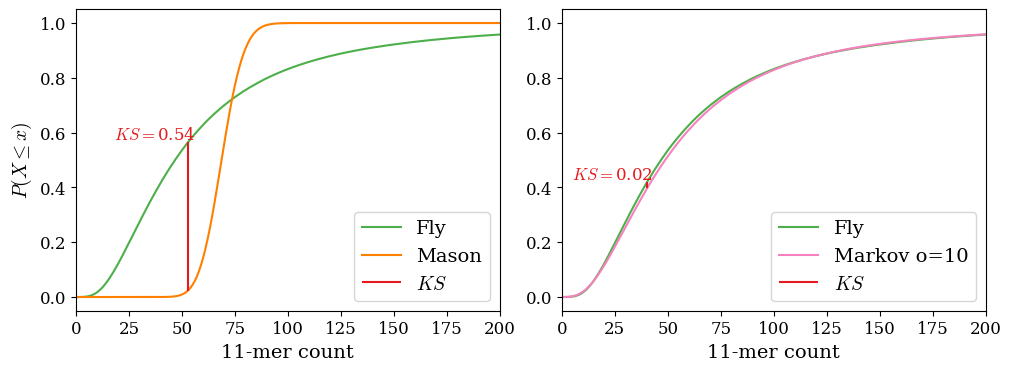

In [22]:
fig = plt.figure(constrained_layout=True)
fig.set_figheight(3.6)
fig.set_figwidth(10)

support = support_set(fly_occ, markov_occ)
support.extend(support_set(fly_occ, mason_occ))
print("Length of support\t" + str(len(support)))
samples = [mason_occ, markov_occ]
names = ["Mason", "Markov o=" + str(o), "Fly"]

subfig = fig.subfigures(nrows=1, ncols=1)
#subfig.suptitle("The Kolmogorov-Smirnov statistic is the maximum divergence between two \n"
#                    "cumulative probability distributions")
axs = subfig.subplots(nrows=1, ncols=2)
plot_ks(ref_cdf, lower, upper, count_sum, samples, axs)

#fig.tight_layout()
fig.savefig('ks_statistic_results.png', dpi = 200)

Length of support	3987
['Mason', 'Markov o=10', 'Fly', 'Fly']
k-mer set size mismatch with diff	11
[0. 0. 0. ... 1. 1. 1.]
KS abs	0.5422116893279544
['Mason', 'Markov o=10', 'Fly', 'Fly']
k-mer set size mismatch with diff	49
[8.77405474e-05 2.95647497e-04 7.63438132e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
KS abs	0.022772931300814425


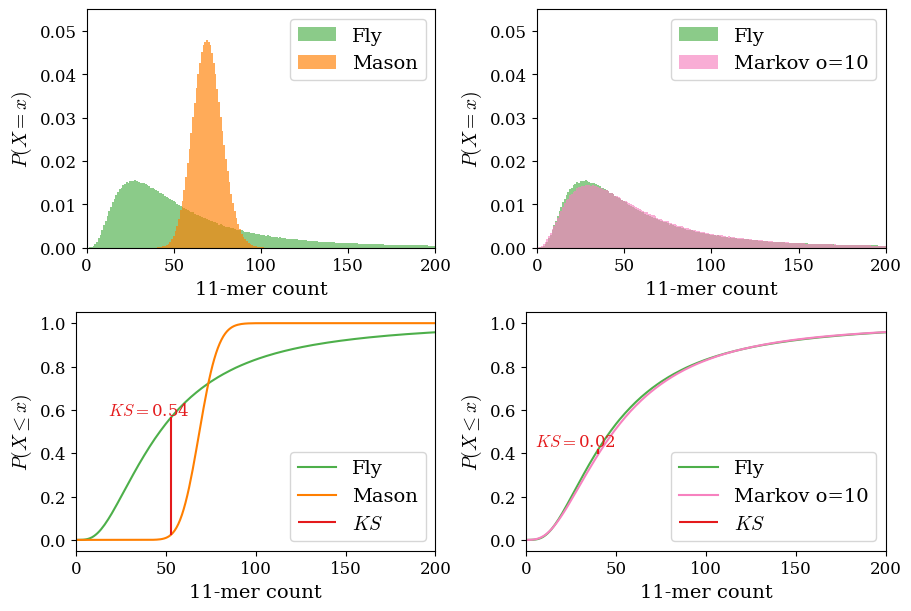

In [23]:
fig = plt.figure(constrained_layout=True)
fig.set_figheight(6)
fig.set_figwidth(9)

support = support_set(fly_occ, markov_occ)
support.extend(support_set(fly_occ, mason_occ))
print("Length of support\t" + str(len(support)))
samples = [mason_occ, markov_occ]
names = ["Mason", "Markov o=" + str(o), "Fly", "Fly"]

subfigs = fig.subfigures(nrows=2, ncols=1)
for row, subfig in enumerate(subfigs):
    if (row == 1):
        #subfig.suptitle("The Kolmogorov-Smirnov statistic is the maximum divergence between two \n"
                        #"cumulative probability distributions")

        axs = subfig.subplots(nrows=1, ncols=2)
        plot_ks(ref_cdf, lower, upper, count_sum, samples, axs)
        axs[1].set_ylabel(r"$P(X \leq x)$")
    else:
        #subfig.suptitle(r"The Jensen-Shannon divergence of a sample distribution S from the true distribution T" + 
                         #"\nis based on the Kullback-Leibler divergence " + 
                        #r"JSD=$\frac{1}{2}D_{KL}(T||M) + \frac{1}{2}D_{KL}(S||M)$")

        axs = subfig.subplots(nrows=1, ncols=2)
        #plot_js(fly_occ, support, samples, axs)
        max_count = 200
        max_freq = 0.055
        for i in range(len(axs)):
            plot_abundance(axs[i], fly_occ, max_count, max_freq, "Fly", fly_color)
        
        plot_abundance(axs[0], mason_occ, max_count, max_freq, "Mason", mason_color)
        plot_abundance(axs[1], markov_occ, max_count, max_freq, "Markov o=" + str(o) + "", markov_color)
        for i in range(len(axs)):        
            axs[i].set_xlim(0, max_count)
            axs[i].set_ylim(0, max_freq)
            axs[i].set_xlabel(str(k) + "-mer count")
            axs[i].legend()
            axs[i].set_ylabel(r"$P(X=x)$")

#fig.tight_layout()
fig.savefig('distribution_ks_divergence.png', dpi = 200)

Length of support	3987
mix_dist	3987
ref_dist	3987
sample_dist	3987
Jensen-Shannon divergence	1.878
mix_dist	3987
ref_dist	3987
sample_dist	3987
Jensen-Shannon divergence	0.001


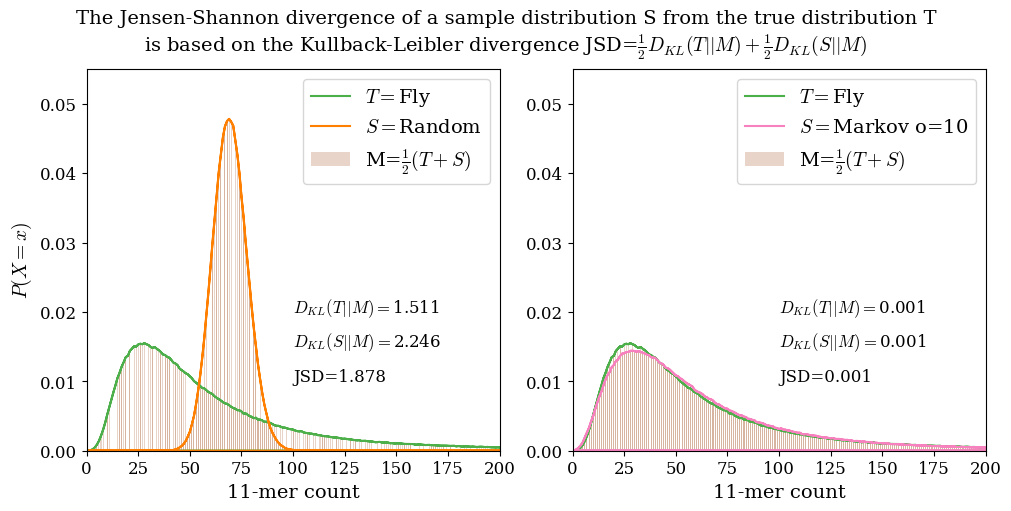

In [20]:
fig, axs = plt.subplots(1, 2, constrained_layout=True)
fig.set_figheight(5)
fig.set_figwidth(10)

support = support_set(fly_occ, markov_occ)
support.extend(support_set(fly_occ, mason_occ))
print("Length of support\t" + str(len(support)))
samples = [mason_occ, markov_occ]
names = ["Random", "Markov o=" + str(o), "Fly", "Fly"]

fig.suptitle(r"The Jensen-Shannon divergence of a sample distribution S from the true distribution T" + 
                 "\nis based on the Kullback-Leibler divergence " + 
                r"JSD=$\frac{1}{2}D_{KL}(T||M) + \frac{1}{2}D_{KL}(S||M)$")
plot_js(fly_occ, support, samples, axs)

#fig.tight_layout()
#fig.savefig('jensen_shannon.png', dpi = 200)

### Model parameter benchmark

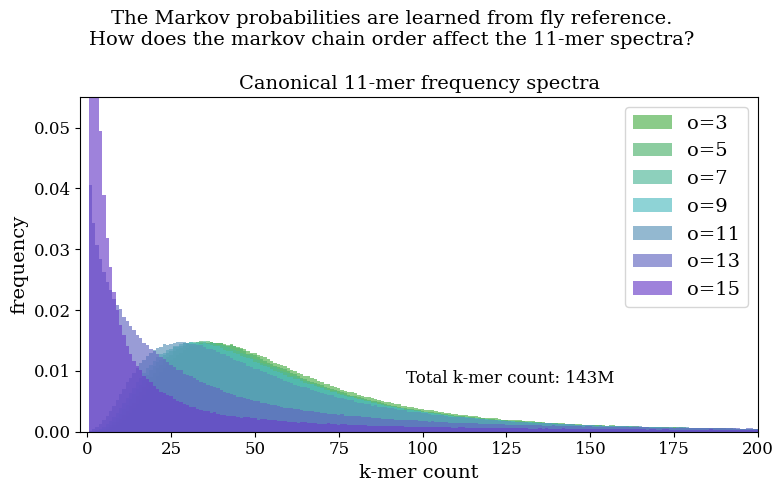

In [21]:
orders = [3, 5, 7, 9, 11, 13, 15]

color_gradient = ["#4DAF4A", "#4EB36D", "#50B898", "#51BCC0", "#5A93B7", "#6367C1", "#6A40C9"]
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
fig.suptitle("The Markov probabilities are learned from fly reference.\n" 
             "How does the markov chain order affect the 11-mer spectra?")

# plot binomial trial
# ax.plot(maso_occ["occurrences"], rand_occ["frequency"], color = CB_color_cycle[6], label = "B(n,p)", alpha = 0.5)

#plot_abundance(ax, fly_occ, 200, 0.055, "Fly", CB_color_cycle[0])
#plot_abundance(ax, mason_occ, 200, 0.055, "Random B(n, p)", CB_color_cycle[1])

i=0
while i < len(orders):
    o = orders[i]
    markov_occ = read_occ_table("data/simulated_fly_size/from_fly_markov_o" + str(o) + ".fa.11mer.tsv")
    plot_abundance(ax, markov_occ, 200, 0.055, "o=" + str(o) + "", color_gradient[i])
    i+=1

ax.text(95, 0.008, "Total k-mer count: 143M", size = SMALL_SIZE)
#ax.text(95, 0.004, "E(x)=" + str(round(np.sum(markov_occ["count"] * markov_occ["occurrences"]) / np.sum(markov_occ["count"]))), size = XSMALL_SIZE)

ax.set_title("Canonical 11-mer frequency spectra")

ax.legend(loc = "upper right")
ax.set_xlabel("k-mer count")
ax.set_ylabel("frequency")

#handles, labels = ax1.get_legend_handles_labels()
#fig.legend(handles, labels, bbox_to_anchor=(0.935,0.75))

fig.tight_layout()
fig.savefig('140Mb_spectra_markov_orders.png', dpi = 200)

In [25]:
k = 7
markov_occ = read_occ_table("data/simulated_fly_size/from_fly_markov_o" + str(o) + ".fa." + str(k) + "mer.tsv")
markov_occ

,count,occurrences,frequency
0,1,3476,0.000122
1,1,3669,0.000122
2,1,3892,0.000122
3,1,3952,0.000122
4,1,4087,0.000122
...,...,...,...
6931,1,106532,0.000122
6932,1,118488,0.000122
6933,1,120855,0.000122
6934,1,126818,0.000122


In [26]:
markov_occ

,count,occurrences,frequency
0,1,3476,0.000122
1,1,3669,0.000122
2,1,3892,0.000122
3,1,3952,0.000122
4,1,4087,0.000122
...,...,...,...
6931,1,106532,0.000122
6932,1,118488,0.000122
6933,1,120855,0.000122
6934,1,126818,0.000122


In [27]:
o = 3
k = 9
markov_occ = read_occ_table("data/simulated_fly_size/from_fly_markov_o" + str(o) + ".fa." + str(k) + "mer.tsv")
np.max(markov_occ["count"])

np.int64(165)

In [28]:
total_var_dist(fly_occ, mason_occ)

np.float64(1548258.5)

In [29]:
total_var_dist(fly_occ, markov_occ)

np.float64(1089906.5)

In [30]:
order_dict = {}
rowname_dict = {}

for o in [3, 5, 7, 9, 11, 13, 15]:
    k_list = []
    i = 0
    for k in [7, 9, 11, 13, 15, 17, 19, 21, 23]:
        markov_occ = read_occ_table("data/simulated_fly_size/from_fly_markov_o" + str(o) + ".fa." + str(k) + "mer.tsv")
        fly_occ = read_occ_table("data/fly/dna4.fasta." + str(k) + "mer.tsv")
        
        var_dist = total_var_dist(fly_occ, markov_occ)
        #print(str(k) + "\t" + str(o) + "\t" + str(var_dist))
        k_list.append(var_dist)
        rowname_dict[i] = k
        i+=1
    order_dict[o] = k_list

var_df = pd.DataFrame(order_dict)
var_df.rename(rowname_dict, inplace = True)
var_df

,3,5,7,9,11,13,15
7,6195.0,6195.0,6222.0,6248.0,6274.0,6744.0,7746.0
9,14770.0,12851.0,12190.0,12150.0,12031.0,51154.0,90864.0
11,246316.0,181244.5,135610.0,97258.5,43815.5,730585.0,1072586.5
13,3383275.0,2761273.0,2283788.0,1914606.0,1327060.0,7458709.0,13337609.0
15,13322582.0,11937159.0,10277995.0,8990876.5,5485433.5,26142003.0,44585536.0
17,16809756.5,16245926.5,15271245.5,14272893.5,11857294.0,18947745.5,55250632.5
19,15725119.0,15670781.0,15549353.0,15267611.0,14418053.0,6071055.5,56560726.5
21,15152147.0,15147142.5,15137000.0,15016608.5,14720035.5,10442429.0,54687492.5
23,14859315.0,14858919.0,14858119.5,14782133.0,14623774.5,12791831.0,47046994.5


Text(0.5, 114.93650793650788, 'model order')

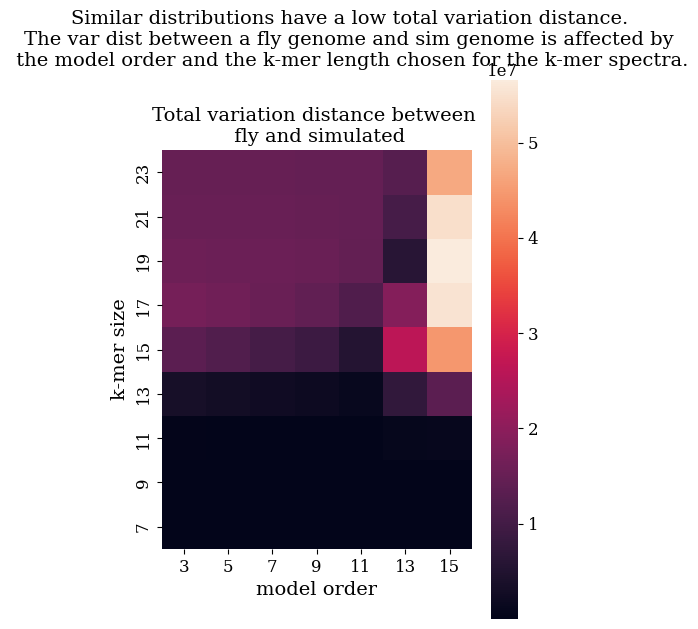

In [31]:
fig, ax = plt.subplots()
fig.set_figheight(7)
fig.set_figwidth(5)
fig.suptitle("Similar distributions have a low total variation distance.\n"
             "The var dist between a fly genome and sim genome is affected by\n"
             " the model order and the k-mer length chosen for the k-mer spectra.")
ax.set_title("Total variation distance between \n fly and simulated")
sns.heatmap(var_df, ax = ax, square = True)
ax.set_ylabel("k-mer size")
ax.invert_yaxis()
ax.set_xlabel("model order")

### Markov model based on mouse genome

In [32]:
mouse_occ = read_occ_table("data/mouse.k11.tsv")
mouse_occ.head()

,count,occurrences,frequency
0,1,62,4.768372e-07
1,1,64,4.768372e-07
2,3,66,1.430511e-06
3,2,67,9.536743e-07
4,5,68,2.384186e-06


In [33]:
human_occ = read_occ_table("data/from_human.k11.tsv")
human_occ.head()

,count,occurrences,frequency
0,127,1,0.000061
1,196,2,0.000093
2,350,3,0.000167
3,411,4,0.000196
4,557,5,0.000266


In [34]:
n = 2762326647
p = 2/(4**11)
x = np.arange(binom.ppf(0.001, n, p),
              binom.ppf(0.999, n, p))

In [35]:
np.argmax(human_occ["count"])

np.int64(52)

In [36]:
human_occ[human_occ["count"] == np.max(human_occ["count"])]

,count,occurrences,frequency
52,2929,53,0.001397


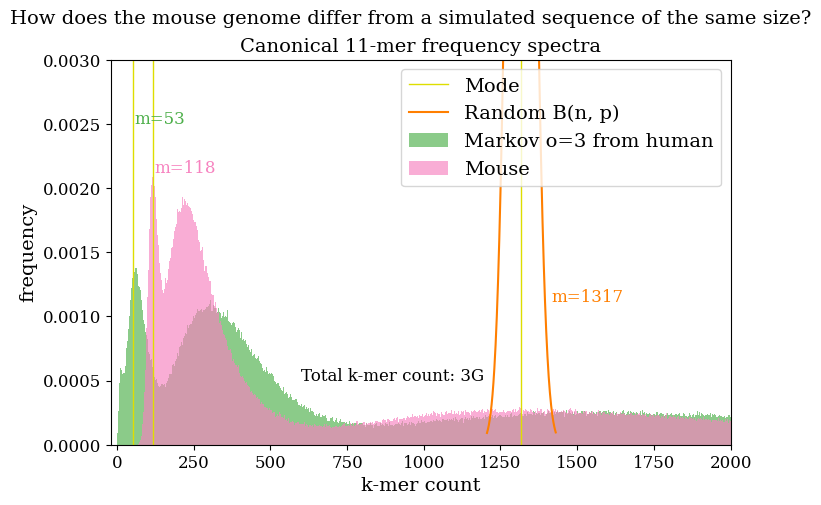

In [37]:
fig, ax = plt.subplots(1)
fig.set_figheight(5)
fig.set_figwidth(8)
fig.suptitle("How does the mouse genome differ from a simulated sequence of the same size?")

plot_abundance(ax, human_occ, 2000, 0.003, "Markov o=3 from human", CB_color_cycle[2])
#plot_abundance(ax, mason_occ, 200, 0.055, "Random", CB_color_cycle[1])
plot_abundance(ax, mouse_occ, 2000, 0.003, "Mouse", CB_color_cycle[3])

ab_mode = human_occ["occurrences"][np.argmax(human_occ["count"])]
ax.axvline(ab_mode, linewidth = 1, label = "Mode", color = CB_color_cycle[8])
ax.text(ab_mode + 3, 0.0025, "m=" + str(ab_mode), size = SMALL_SIZE, color = CB_color_cycle[2])

ab_mode = mouse_occ["occurrences"][np.argmax(mouse_occ["count"])]
ax.axvline(ab_mode, linewidth = 1, color = CB_color_cycle[8])
ax.text(ab_mode + 3, mouse_occ["frequency"][np.argmax(mouse_occ["count"])], "m=" + str(ab_mode), size = SMALL_SIZE, color = CB_color_cycle[3])

ax.plot(x, binom.pmf(x, n, p), color = CB_color_cycle[1], ms=8, label='Random B(n, p)')
#ax.vlines(x, 0, binom.pmf(x, n, p), color = CB_color_cycle[1], colors='b', lw=5, alpha=0.03, label = "Random B(n, p)")
ab_mode = int(n * p)
#ax.axvline(ab_mode, linewidth = 1, color = CB_color_cycle[1], alpha = 0.75)
ax.axvline(ab_mode, linewidth = 1, color = CB_color_cycle[8])
ax.text(ab_mode + 100, mouse_occ["frequency"][np.argmax(mouse_occ["count"])] - 0.001, "m=" + str(ab_mode), size = SMALL_SIZE, color = CB_color_cycle[1])

#ab_mode = rand_occ["occurrences"][np.argmax(rand_occ["count"])]
#ax.axvline(ab_mode, linewidth = 1, color = CB_color_cycle[4], alpha = 0.75)

#ax.text(95, 0.008, "Total k-mer count: 143M", size = XSMALL_SIZE)
#ax.text(95, 0.004, "E(x)=" + str(round(np.sum(markov_occ["count"] * markov_occ["occurrences"]) / np.sum(markov_occ["count"]))), size = XSMALL_SIZE)

#ax.text(110, 0.005, "Max k-mer count: " + str(np.max(fly_occ["occurrences"])), size = XSMALL_SIZE, color = c_darkgreen)
#ax.text(110, 0.02, "Total k-mer count: " + str(np.sum(markov_occ["count"] * markov_occ["occurrences"])), size = XSMALL_SIZE, color = CB_color_cycle[6])

ax.text(600, 0.0005, "Total k-mer count: 3G", size = SMALL_SIZE)

ax.set_title("Canonical 11-mer frequency spectra")

ax.legend(loc = "upper right")
ax.set_xlabel("k-mer count")
ax.set_ylabel("frequency")

#handles, labels = ax1.get_legend_handles_labels()
#fig.legend(handles, labels, bbox_to_anchor=(0.935,0.75))

fig.savefig('mouse_vs_human.pdf', dpi = 200)
plt.show()

In [38]:
import collections

col = "occurrences"
dependent_col = "count"    
def cumulative_distribution_function(df, val_range):
    cum_dist = []
    sum_i = 0

    df = df.sort_values(by = [col])
    df = df.reset_index(drop = True)

    distance = 0
    for i in val_range:
        row = df[df[col] == i] 
        #print(row[dependent_col])
        index = int(row.index.values.tolist()[0])
        #print(index)
        #print("Index\t" + str(index))
        #print("iloc[index]\t" + str(df.iloc[index][col]))
        if (index > 0):
            distance = int(df.iloc[index][col] - df.iloc[index-1][col])
            #print("dist\t" + str(dist))
            #print("Gathered value count\t" + str(len(cum_dist)))
        sum_i += int(row[dependent_col].iloc[0])
        cum_dist.append(sum_i)
    
    return cum_dist

In [39]:
print(ref_cdf)

[2.47956623e-05 1.12534160e-04 3.20913091e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]


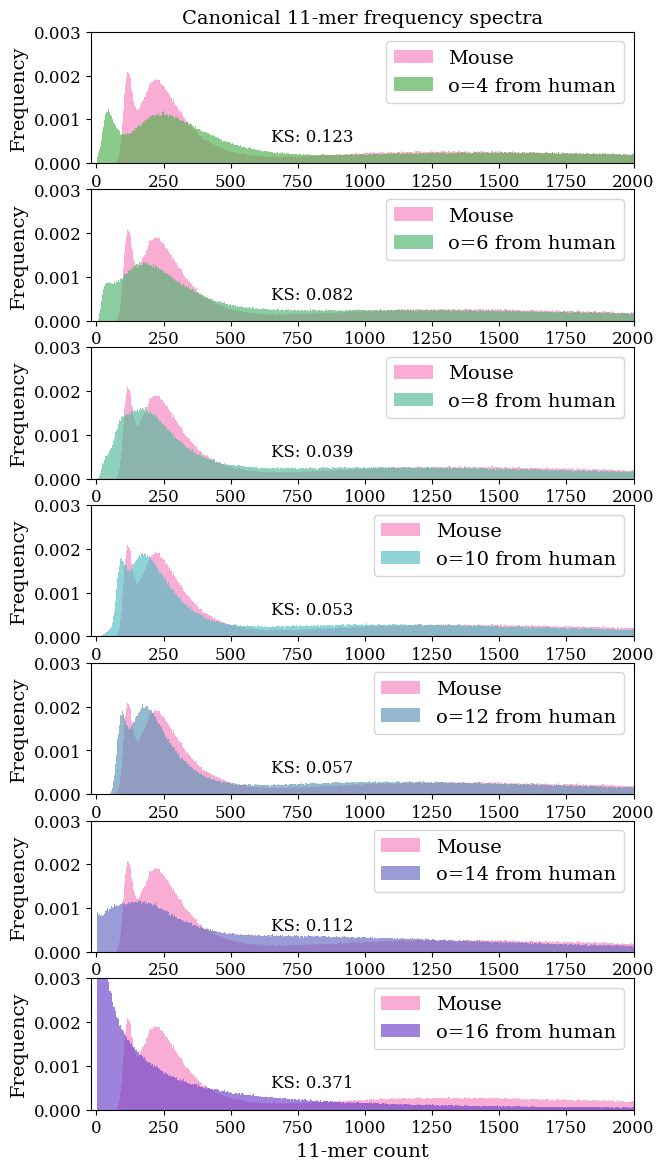

In [42]:
color_gradient = ["#4DAF4A", "#4EB36D", "#50B898", "#51BCC0", "#5A93B7", "#6367C1", "#6A40C9"]
orders = [4, 6, 8, 10, 12, 14, 16]
k = 11

fig, ax = plt.subplots(len(orders), 1)
fig.set_figheight(len(orders) * 2)
fig.set_figwidth(7)

#fig.suptitle("Markov probabilities are learned from human reference.\n"
#             "How does the markov chain order affect the " + str(k) + "-mer frequency?")

mouse_occ = read_occ_table("data/mouse/dna4.fasta." + str(k) + "mer.tsv")

i=0
while i < len(orders):
    o = orders[i]
    plot_abundance(ax[i], mouse_occ, 2000, 0.003, "Mouse", CB_color_cycle[3])
    markov_occ = read_occ_table("data/simulated_mouse_size/from_human_markov_o" + str(o) + ".fa." + str(k) + "mer.tsv")
    plot_abundance(ax[i], markov_occ, 2000, 0.003, "o=" + str(o) +" from human", color_gradient[i])

    var_dist = total_var_dist(mouse_occ, markov_occ)

    occ_val_intersection = collections.Counter(list(mouse_occ[col])) & collections.Counter(list(markov_occ[col]))
    val_range = list(occ_val_intersection.elements())

    reference = mouse_occ
    sample = markov_occ
    ref_cdf = cumulative_distribution_function(reference, val_range)
    count_sum = np.sum(reference["count"])
    ref_cdf = ref_cdf / count_sum

    sample_cdf = cumulative_distribution_function(sample, val_range) / count_sum
    ks_abs = kolmogorov_smirnov_statistic_abs(ref_cdf, sample_cdf) 

    #ax[i].text(650, 0.001, "tot var dist: " + f"{int(var_dist):,d}", size = SMALL_SIZE)
    ax[i].text(650, 0.0005, "KS: " + str(round(ks_abs, 3)), size = SMALL_SIZE)
    
    ax[i].legend(loc = "upper right")
    ax[i].set_ylabel("Frequency")
    i+=1

ax[0].set_title("Canonical " + str(k) + "-mer frequency spectra")
ax[len(orders) - 1].set_xlabel(str(k) + "-mer count")

#handles, labels = ax1.get_legend_handles_labels()
#fig.legend(handles, labels, bbox_to_anchor=(0.935,0.75))

fig.savefig('from_human_mouse_size_order_' + str(k) + '.png', dpi = 200)
plt.show()